<a href="https://colab.research.google.com/github/sadiq937/Shaik_DM/blob/main/PS5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PS5 - DATAMANGEMENT

#Macro-Financial Analysis and Stock Price Forecasting: Exploring the Impact of Economic Indicators on Market Trends

📄 Abstract — Final Presentation (S5): Macro-Financial Analysis and Stock Price Forecasting
This project offers a comprehensive exploration of the dynamic relationship between key macroeconomic indicators and the stock market performance of major technology firms, specifically Apple and Nvidia. The goal is to understand how variables such as the S&P 500 Index, Consumer Price Index (CPI), Federal Funds Rate, Real GDP Growth Rate, and Unemployment Rate influence stock behavior over time, and how this relationship can be leveraged for predictive modeling.

Macroeconomic data is sourced via the Federal Reserve Economic Data (FRED) API, while historical monthly stock prices for Apple and Nvidia are retrieved using the Alpha Vantage API. This data is cleaned, merged, and transformed to analyze temporal trends and percentage changes. Using techniques like stacking/unstacking, long-format reshaping, and fuzzy matching (via the fuzzywuzzy package), we standardize indicator names and align data from disparate sources, ensuring consistency across the dataset.

The analysis employs interactive and insightful visualizations built with Plotly, including:

Correlation Heatmap to quantify relationships between economic indicators

Time-Series Line Plot for S&P 500 trend tracking

Scatter Plot showing CPI vs. Interest Rate interaction

Market Trend Bar Chart classifying market states as Boom, Downturn, or Stable based on S&P 500 volatility

Area Plot to highlight collective macroeconomic movements over time

In the advanced phase of this project, a deep learning-based Long Short-Term Memory (LSTM) model is developed to forecast future stock prices for Apple, using historical closing prices. The model is trained on 95% of the scaled data, with 60-day rolling windows, and tested on the remaining 5%. Forecast performance is evaluated using RMSE, and predictions are visualized against actual prices to assess trend capture and deviation.

The project further compares the performance of Apple and Nvidia by analyzing their return distributions and stock-specific responsiveness to macroeconomic factors. Feature importance from Random Forest models provides interpretability on which economic indicators most strongly influence stock returns.

By combining macro-level economic analysis with micro-level stock forecasting, this work bridges the gap between financial economics and machine learning. The findings demonstrate both the interpretability of macroeconomic influences on markets and the applicability of LSTM models for real-world stock forecasting. The study concludes with a critical reflection on the model's assumptions, limitations, and suggestions for future improvements such as integrating sentiment analysis, using multivariate LSTM models, and expanding stock coverage across multiple sectors.

## INSTALLING DEPENDENCIES

In [23]:
!pip install fuzzywuzzy

In [24]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.4 MB/s eta 0:00:00


In [25]:
!pip install yfinance

In [29]:
import requests
import os
import pandas as pd
import numpy as np
import re
import time
import plotly.express as px
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
import folium
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import yfinance as yf
import requests
from io import StringIO


## LOADING DATASETS - API

In [32]:
from google.colab import userdata
userdata.get('FRED_API_KEY')
userdata.get('ALPHA_VANTAGE_API_KEY')

'VFIZUTBYB83CVEXI'

In [36]:
from google.colab import userdata
userdata.get('FRED_API_KEY')

# Function to fetch data from FRED
def fetch_fred_data(series_id, start_date="2000-01-01", end_date=str(datetime.today().date())):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json&observation_start={start_date}&observation_end={end_date}"
    response = requests.get(url).json()
    data = response.get("observations", [])
    return pd.DataFrame([{"date": obs["date"], series_id: float(obs["value"])} for obs in data if obs["value"] != "."])

In [37]:
# Function to fetch data from Alpha Vantage
from google.colab import userdata
userdata.get('ALPHA_VANTAGE_API_KEY')

def fetch_alpha_vantage_data(function, symbol, interval="Monthly", start_date="2000-01-01", end_date=str(datetime.today().date())):
    url = f"https://www.alphavantage.co/query?function={function}&symbol={symbol}&interval={interval}&apikey={ALPHA_VANTAGE_API_KEY}&datatype=csv"
    response = requests.get(url).text
    df = pd.read_csv(StringIO(response))
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]
    return df[['timestamp', 'close']].rename(columns={'timestamp': 'date', 'close': symbol})

In [38]:
# S&P 500 Index
sp500_df = fetch_fred_data("SP500")
sp500_df.head()

,date,SP500
0,2015-04-29,2106.85
1,2015-04-30,2085.51
2,2015-05-01,2108.29
3,2015-05-04,2114.49
4,2015-05-05,2089.46


In [39]:
# Consumer Price Index
inflation_df = fetch_fred_data("CPIAUCSL")
inflation_df.head()

,date,CPIAUCSL
0,2000-01-01,169.3
1,2000-02-01,170.0
2,2000-03-01,171.0
3,2000-04-01,170.9
4,2000-05-01,171.2


In [40]:
# Fedral Funds Rate
interest_rate_df = fetch_fred_data("FEDFUNDS")
interest_rate_df.head()

,date,FEDFUNDS
0,2000-01-01,5.45
1,2000-02-01,5.73
2,2000-03-01,5.85
3,2000-04-01,6.02
4,2000-05-01,6.27


In [41]:
# Real GDP Growth Rate
gdp_df = fetch_fred_data("A191RL1Q225SBEA")
gdp_df.head()

,date,A191RL1Q225SBEA
0,2000-01-01,1.5
1,2000-04-01,7.5
2,2000-07-01,0.4
3,2000-10-01,2.4
4,2001-01-01,-1.3


In [42]:
# Unemployment Rate
unemployment_df = fetch_fred_data("UNRATE")
unemployment_df.head()

,date,UNRATE
0,2000-01-01,4.0
1,2000-02-01,4.1
2,2000-03-01,4.0
3,2000-04-01,3.8
4,2000-05-01,4.0


In [46]:
# Fetching stock data from Alpha Vantage API (APPLE)
from google.colab import userdata
ALPHA_VANTAGE_API_KEY = userdata.get('ALPHA_VANTAGE_API_KEY')
apple_stock_df = fetch_alpha_vantage_data("TIME_SERIES_MONTHLY", "AAPL")
apple_stock_df.head()

,date,AAPL
0,2025-04-28,210.14
1,2025-03-31,222.13
2,2025-02-28,241.84
3,2025-01-31,236.00
4,2024-12-31,250.42


In [47]:
# Fetching stock data from Alpha Vantage API (NVIDIA)
nvidia_stock_df = fetch_alpha_vantage_data("TIME_SERIES_MONTHLY", "NVDA")
nvidia_stock_df.head()

,date,NVDA
0,2025-04-28,108.73
1,2025-03-31,108.38
2,2025-02-28,124.92
3,2025-01-31,120.07
4,2024-12-31,134.29


## MERGING DATASETS

In [48]:
macro_df = sp500_df.merge(inflation_df, on="date", how="inner")\
                      .merge(interest_rate_df, on="date", how="inner")\
                      .merge(gdp_df, on="date", how="inner")\
                      .merge(unemployment_df, on="date", how="inner")

macro_df["date"] = pd.to_datetime(macro_df["date"])
macro_df.set_index("date", inplace=True)
macro_df.head()

,SP500,CPIAUCSL,FEDFUNDS,A191RL1Q225SBEA,UNRATE
date,,,,,
2015-07-01,2077.42,238.034,0.13,1.6,5.2
2015-10-01,1923.82,237.733,0.12,0.7,5.0
2016-04-01,2072.78,238.992,0.37,1.3,5.1
2016-07-01,2102.95,240.101,0.39,2.9,4.8
2018-10-01,2924.59,252.772,2.19,0.6,3.8


In [49]:
# Compute percentage changes
pct_change_df = macro_df.pct_change().dropna()
pct_change_df.head()

,SP500,CPIAUCSL,FEDFUNDS,A191RL1Q225SBEA,UNRATE
date,,,,,
2015-10-01,-0.073938,-0.001265,-0.076923,-0.562500,-0.038462
2016-04-01,0.077429,0.005296,2.083333,0.857143,0.020000
2016-07-01,0.014555,0.004640,0.054054,1.230769,-0.058824
2018-10-01,0.390708,0.052774,4.615385,-0.793103,-0.208333
2019-04-01,-0.019627,0.009736,0.105023,4.666667,-0.026316


## STACK/ UNSTACK

In [50]:
long_format_df = pct_change_df.stack().reset_index()
long_format_df.columns = ["date", "indicator", "value"]
long_format_df.head()

,date,indicator,value
0,2015-10-01,SP500,-0.073938
1,2015-10-01,CPIAUCSL,-0.001265
2,2015-10-01,FEDFUNDS,-0.076923
3,2015-10-01,A191RL1Q225SBEA,-0.562500
4,2015-10-01,UNRATE,-0.038462


## MARKET TREND CATEGORY

In [51]:
def categorize_market(value):
    if value > 0.02:
        return "Boom"
    elif value < -0.02:
        return "Downturn"
    else:
        return "Stable"

pct_change_df["Market_Trend"] = pct_change_df["SP500"].apply(categorize_market)
pct_change_df.head()

,SP500,CPIAUCSL,FEDFUNDS,A191RL1Q225SBEA,UNRATE,Market_Trend
date,,,,,,
2015-10-01,-0.073938,-0.001265,-0.076923,-0.562500,-0.038462,Downturn
2016-04-01,0.077429,0.005296,2.083333,0.857143,0.020000,Boom
2016-07-01,0.014555,0.004640,0.054054,1.230769,-0.058824,Stable
2018-10-01,0.390708,0.052774,4.615385,-0.793103,-0.208333,Boom
2019-04-01,-0.019627,0.009736,0.105023,4.666667,-0.026316,Stable


## RESHAPE (PIVOT)

In [52]:
pivot_df = long_format_df.pivot(index="date", columns="indicator", values="value")
pivot_df.head()

indicator,A191RL1Q225SBEA,CPIAUCSL,FEDFUNDS,SP500,UNRATE
date,,,,,
2015-10-01,-0.562500,-0.001265,-0.076923,-0.073938,-0.038462
2016-04-01,0.857143,0.005296,2.083333,0.077429,0.020000
2016-07-01,1.230769,0.004640,0.054054,0.014555,-0.058824
2018-10-01,-0.793103,0.052774,4.615385,0.390708,-0.208333
2019-04-01,4.666667,0.009736,0.105023,-0.019627,-0.026316


## CORRELATION MATRIX

In [53]:
numerical_df = pct_change_df.select_dtypes(include=['number'])
correlation_matrix_df = numerical_df.corr()
correlation_matrix_df

,SP500,CPIAUCSL,FEDFUNDS,A191RL1Q225SBEA,UNRATE
SP500,1.000000,0.679210,0.368073,-0.035030,-0.396294
CPIAUCSL,0.679210,1.000000,0.720566,0.179440,-0.275009
FEDFUNDS,0.368073,0.720566,1.000000,0.379848,-0.291805
A191RL1Q225SBEA,-0.035030,0.179440,0.379848,1.000000,-0.723314
UNRATE,-0.396294,-0.275009,-0.291805,-0.723314,1.000000


## VISUALIZATIONS

In [ ]:
fig1 = px.imshow(correlation_matrix_df, text_auto=True, color_continuous_scale='RdBu_r', title="Correlation Between Macroeconomic Indicators")
fig1.show()


## TREND OF S&P 500 over time

In [54]:
df_reset = pct_change_df.reset_index()
fig2 = px.line(df_reset, x="date", y="SP500", title="S&P 500 Trend Over Time", labels={"SP500": "S&P 500 Returns"})
fig2.show()

## Inflation vs interest rate

In [55]:

# Scatter plot of Inflation vs. Interest Rates
fig3 = px.scatter(df_reset, x="CPIAUCSL", y="FEDFUNDS", title="Inflation vs. Interest Rates", labels={"CPIAUCSL": "Inflation (CPI)", "FEDFUNDS": "Interest Rate"}, trendline="ols")
fig3.show()


## MARKET TREND BAR CHART

In [56]:
# Bar chart for market trend categories
market_trend_counts_df = pct_change_df["Market_Trend"].value_counts().reset_index()
market_trend_counts_df.columns = ["Trend", "Count"]
fig4 = px.bar(market_trend_counts_df, x="Trend", y="Count", title="Market Trend Distribution", color="Trend")
fig4.show()

## MACROECONOMIC INDICATORS OVER TIME

In [57]:
# Time-series area plot
fig5 = px.area(df_reset, x="date", y=["SP500", "CPIAUCSL", "FEDFUNDS", "A191RL1Q225SBEA", "UNRATE"], title="Macroeconomic Indicators Over Time", labels={"value": "Percentage Change", "variable": "Indicator"})
fig5.show()

## FUZZYWUZZY

In [58]:
fuzzy_data_df = pd.DataFrame({"Indicator_Names": ["CPIAUCSL", "FED Funds Rate", "SP 500", "CPI", "AAPL Stock"]})

def match_indicator_name(indicator_name):
    threshold = 50

    # Check similarity ratios for each comparison
    similarity_score_cpi = fuzz.ratio(indicator_name, "Consumer Price Index")
    similarity_score_fed = fuzz.ratio(indicator_name, "Federal Funds Rate")
    similarity_score_sp500 = fuzz.ratio(indicator_name, "S&P 500 Index")
    similarity_score_apple = fuzz.ratio(indicator_name, "Apple Stock")

    # Print similarity scores for each match attempt
    print(f"Matching '{indicator_name}' with 'Consumer Price Index' gives score: {similarity_score_cpi}")
    print(f"Matching '{indicator_name}' with 'Federal Funds Rate' gives score: {similarity_score_fed}")
    print(f"Matching '{indicator_name}' with 'S&P 500 Index' gives score: {similarity_score_sp500}")
    print(f"Matching '{indicator_name}' with 'Apple Stock' gives score: {similarity_score_apple}")

    # Determine the best match based on the highest similarity score
    if similarity_score_cpi > threshold:
        return "Consumer Price Index"
    elif similarity_score_fed > threshold:
        return "Federal Funds Rate"
    elif similarity_score_sp500 > threshold:
        return "S&P 500 Index"
    elif similarity_score_apple > threshold:
        return "Apple Stock"
    else:
        return indicator_name

fuzzy_data_df["Matched_Names"] = fuzzy_data_df["Indicator_Names"].apply(match_indicator_name)
fuzzy_data_df

Matching 'CPIAUCSL' with 'Consumer Price Index' gives score: 21
Matching 'CPIAUCSL' with 'Federal Funds Rate' gives score: 0
Matching 'CPIAUCSL' with 'S&P 500 Index' gives score: 19
Matching 'CPIAUCSL' with 'Apple Stock' gives score: 21
Matching 'FED Funds Rate' with 'Consumer Price Index' gives score: 24
Matching 'FED Funds Rate' with 'Federal Funds Rate' gives score: 75
Matching 'FED Funds Rate' with 'S&P 500 Index' gives score: 30
Matching 'FED Funds Rate' with 'Apple Stock' gives score: 16
Matching 'SP 500' with 'Consumer Price Index' gives score: 15
Matching 'SP 500' with 'Federal Funds Rate' gives score: 8
Matching 'SP 500' with 'S&P 500 Index' gives score: 63
Matching 'SP 500' with 'Apple Stock' gives score: 12
Matching 'CPI' with 'Consumer Price Index' gives score: 26
Matching 'CPI' with 'Federal Funds Rate' gives score: 0
Matching 'CPI' with 'S&P 500 Index' gives score: 25
Matching 'CPI' with 'Apple Stock' gives score: 0
Matching 'AAPL Stock' with 'Consumer Price Index' gives 

,Indicator_Names,Matched_Names
0,CPIAUCSL,CPIAUCSL
1,FED Funds Rate,Federal Funds Rate
2,SP 500,S&P 500 Index
3,CPI,CPI
4,AAPL Stock,Apple Stock


In [59]:
# Merge Apple and Nvidia into macro dataset
combined_stock_df = apple_stock_df.merge(nvidia_stock_df, on="date", how="inner")
full_df = macro_df.reset_index().merge(combined_stock_df, on="date", how="inner").dropna()

# Set 'date' as datetime index
full_df['date'] = pd.to_datetime(full_df['date'])
full_df.set_index('date', inplace=True)

# Compute percentage changes
full_pct_df = full_df.pct_change().dropna()

# Define target returns
full_pct_df['AAPL_Returns'] = full_pct_df['AAPL']
full_pct_df['NVDA_Returns'] = full_pct_df['NVDA']
full_pct_df.drop(columns=['AAPL', 'NVDA'], inplace=True)

full_pct_df.head()




,SP500,CPIAUCSL,FEDFUNDS,A191RL1Q225SBEA,UNRATE,AAPL_Returns,NVDA_Returns
date,,,,,,,


In [60]:
full_pct_df

,SP500,CPIAUCSL,FEDFUNDS,A191RL1Q225SBEA,UNRATE,AAPL_Returns,NVDA_Returns
date,,,,,,,


In [61]:
FRED_API_KEY = userdata.get('FRED_API_KEY')

def fetch_fred_data(series_id):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json"
    response = requests.get(url).json()
    data = response.get("observations", [])
    return pd.DataFrame([{"date": obs["date"], series_id: float(obs["value"])} for obs in data if obs["value"] != "."])

macro_indicators = {
    "SP500": "S&P 500",
    "CPIAUCSL": "Consumer Price Index",
    "FEDFUNDS": "Federal Funds Rate",
    "A191RL1Q225SBEA": "Real GDP Growth",
    "UNRATE": "Unemployment Rate"
}

macro_df = None
for code in macro_indicators:
    df = fetch_fred_data(code)
    df["date"] = pd.to_datetime(df["date"])
    if macro_df is None:
        macro_df = df
    else:
        macro_df = pd.merge(macro_df, df, on="date", how="inner")

macro_df.set_index("date", inplace=True)
macro_pct_df = macro_df.pct_change().dropna()

In [62]:
macro_pct_df

,SP500,CPIAUCSL,FEDFUNDS,A191RL1Q225SBEA,UNRATE
date,,,,,
2015-10-01,-0.073938,-0.001265,-0.076923,-0.562500,-0.038462
2016-04-01,0.077429,0.005296,2.083333,0.857143,0.020000
2016-07-01,0.014555,0.004640,0.054054,1.230769,-0.058824
2018-10-01,0.390708,0.052774,4.615385,-0.793103,-0.208333
2019-04-01,-0.019627,0.009736,0.105023,4.666667,-0.026316
2019-07-01,0.033880,0.002229,-0.008264,0.411765,0.000000
2019-10-01,-0.008123,0.005289,-0.237500,-0.416667,-0.027027
2020-04-01,-0.159765,-0.004367,-0.972678,-11.035714,3.111111
2020-07-01,0.261226,0.009061,0.800000,-2.252669,-0.310811


In [63]:
tech_list = ['AAPL', 'NVDA' ,'GOOG', 'MSFT', 'AMZN']
end = datetime.now()
start = datetime(end.year - 5, end.month, end.day)

stock_data = {}
for symbol in tech_list:
    stock_data[symbol] = yf.download(symbol, start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [64]:
for symbol in tech_list:
    # Use 'Close' instead of 'Adj Close' if it exists, otherwise use 'Adj Close'
    close_col = 'Close' if 'Close' in stock_data[symbol].columns else 'Adj Close'
    stock_data[symbol]['MA20'] = stock_data[symbol][close_col].rolling(20).mean()
    stock_data[symbol]['Daily Return'] = stock_data[symbol][close_col].pct_change()

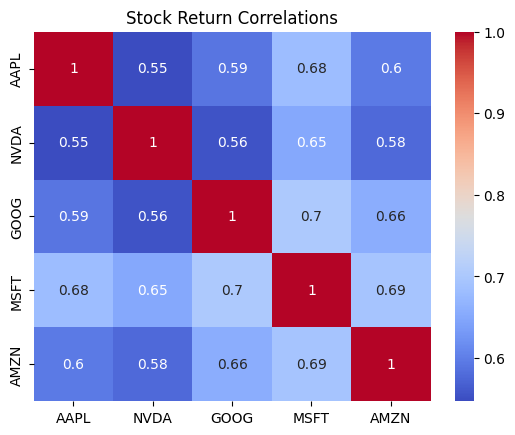

In [65]:
closing_df = pd.concat([stock_data[s]['Close'] for s in tech_list], axis=1)
closing_df.columns = tech_list
returns_df = closing_df.pct_change().dropna()
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Return Correlations")
plt.show()


In [66]:
apple_df = stock_data['AAPL'][['Close']]

apple_values = apple_df.values
training_data_len = int(np.ceil(len(apple_values) * 0.95))

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(apple_values)
train_data = scaled_data[:training_data_len, :]

x_train, y_train = [], []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(64),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=1, epochs=1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1134/1134 ━━━━━━━━━━━━━━━━━━━━ 62s 51ms/step - loss: 0.0109


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step


<ipython-input-67-85e4588d3dce>:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



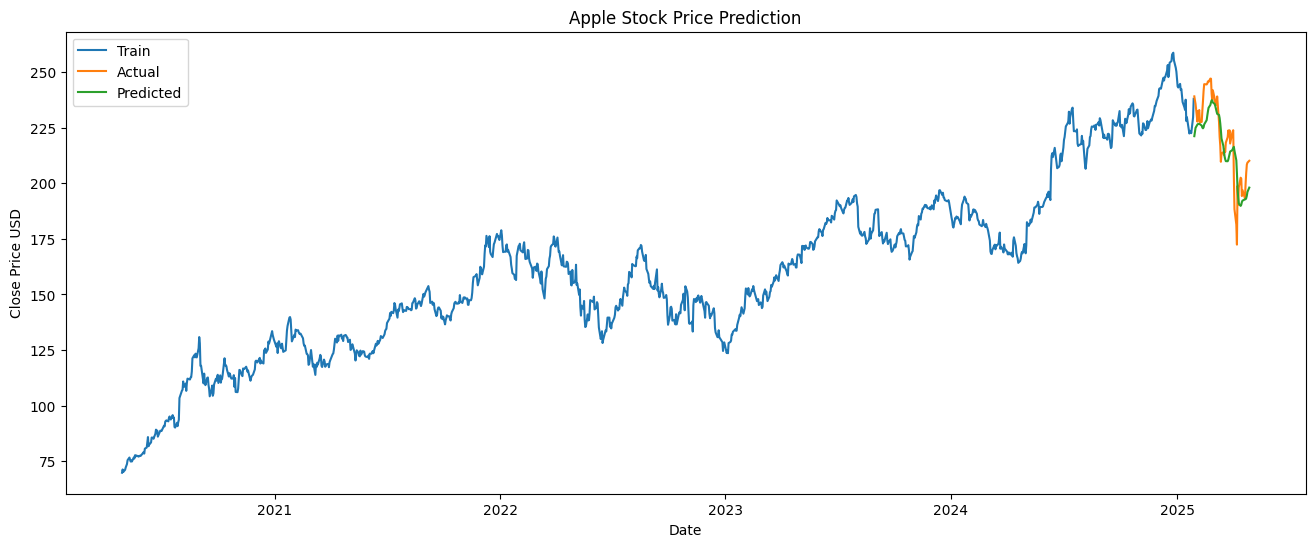

In [67]:
test_data = scaled_data[training_data_len - 60:]
x_test = []
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

valid = apple_df.iloc[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Apple Stock Price Prediction')
plt.plot(apple_df['Close'][:training_data_len], label='Train')
plt.plot(valid[['Close']], label='Actual')
plt.plot(valid[['Predictions']], label='Predicted')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.show()